# E-Commerce Revenue Forecasting

## 1. Project Overview

This project builds a revenue forecasting pipeline using the Olist Brazilian e-commerce dataset.

The objective is to predict future monthly revenue by comparing:

1. ARIMA statistical forecasting model
2. XGBoost machine learning forecasting model

The workflow includes:

- Data integration
- Exploratory analysis
- Time-series feature engineering
- Model training
- Forecast evaluation using MAE and RMSE

## 2. Project Workflow

The project follows an end-to-end revenue forecasting pipeline:

```text
                 Data Sources
                      |
                      v
        Orders Dataset + Payments Dataset
                      |
                      v
              Data Integration
          (Merge orders and payments)
                      |
                      v
              Data Exploration
     (Data types, missing values, structure)
                      |
                      v
          Revenue Aggregation
     (Monthly revenue calculation)
                      |
                      v
     Exploratory Time-Series Analysis
        (Revenue trends over time)
                      |
                      v
            Train/Test Split
        (Six-month holdout testing)
                      |
          +-----------+-----------+
          |                       |
          v                       v
   ARIMA Forecasting      XGBoost Forecasting
  (Statistical Model)    (ML + Feature Engineering)
          |                       |
          +-----------+-----------+
                      |
                      v
            Model Evaluation
          (MAE and RMSE)
                      |
                      v
          Feature Importance
      (XGBoost Interpretation)
                      |
                      v
                 Conclusion
      (Best Forecasting Model)
```

## 3. Libraries Used

- Pandas
- NumPy
- Matplotlib
- Statsmodels (ARIMA)
- XGBoost
- Scikit-learn

In [370]:
pip install pandas matplotlib scikit-learn statsmodels xgboost

Note: you may need to restart the kernel to use updated packages.


In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

## 4. Load Data

In [372]:
orders = pd.read_csv("olist_orders_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

In [373]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [374]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


## 5. Data Exploration

In [375]:
orders.info()
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  obje

## 6. Missing Value Analysis

In [376]:
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [377]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

## 7. Revenue Aggregation

In [378]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [379]:
df = orders.merge(
    payments,
    on="order_id",
    how="left"
)

In [380]:
df["month"] = (
    df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)


monthly_revenue = (
    df.groupby("month")
    ["payment_value"]
    .sum()
    .reset_index()
)


monthly_revenue.columns = [
    "month",
    "revenue"
]


monthly_revenue.head()

,month,revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


In [381]:
monthly_revenue.to_csv(
    "monthly_revenue.csv",
    index=False
)

## 8. Exploratory Time-Series Analysis

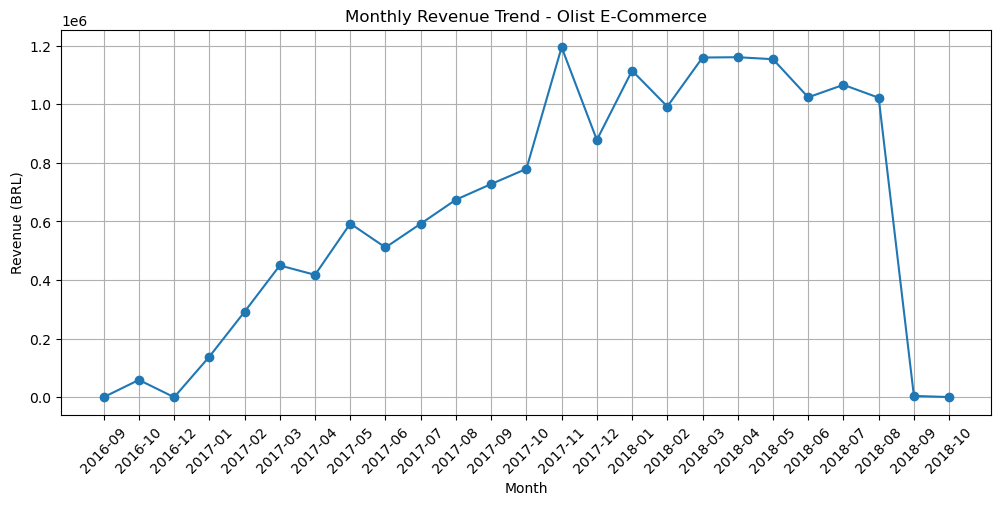

In [382]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title(
    "Monthly Revenue Trend - Olist E-Commerce"
)

plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## 9. ARIMA Forecasting

In [383]:
arima_data = monthly_revenue.copy()

arima_data["month"] = pd.to_datetime(
    arima_data["month"]
)

arima_data = arima_data.sort_values(
    "month"
)

In [384]:
train = arima_data.iloc[:-6]

test = arima_data.iloc[-6:]

In [385]:
arima_model = ARIMA(
    train["revenue"],
    order=(1,1,1)
)


arima_fit = arima_model.fit()


arima_forecast = arima_fit.forecast(
    steps=6
)

In [386]:
arima_results = test.copy()

arima_results["prediction"] = (
    arima_forecast.values
)


arima_mae = mean_absolute_error(
    arima_results["revenue"],
    arima_results["prediction"]
)


arima_rmse = np.sqrt(
    mean_squared_error(
        arima_results["revenue"],
        arima_results["prediction"]
    )
)


print(
    f"ARIMA MAE: {arima_mae:,.2f}"
)

print(
    f"ARIMA RMSE: {arima_rmse:,.2f}"
)

ARIMA MAE: 502,347.62
ARIMA RMSE: 710,644.07


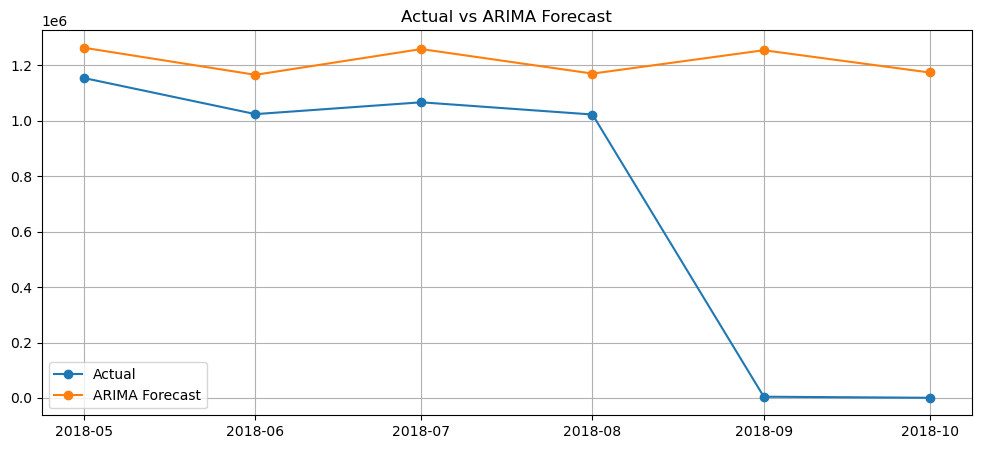

In [387]:
plt.figure(figsize=(12,5))


plt.plot(
    arima_results["month"],
    arima_results["revenue"],
    marker="o",
    label="Actual"
)


plt.plot(
    arima_results["month"],
    arima_results["prediction"],
    marker="o",
    label="ARIMA Forecast"
)


plt.title(
    "Actual vs ARIMA Forecast"
)

plt.legend()
plt.grid(True)

plt.show()

## 10. XGBoost Forecasting

In [388]:
df = monthly_revenue.copy()

df["month"] = pd.to_datetime(df["month"])


df["year"] = df["month"].dt.year

df["month_number"] = df["month"].dt.month

df["quarter"] = df["month"].dt.quarter

In [389]:
df["lag_1"] = df["revenue"].shift(1)

df["lag_2"] = df["revenue"].shift(2)

df["lag_3"] = df["revenue"].shift(3)

df["lag_6"] = df["revenue"].shift(6)

In [390]:
df["rolling_mean_3"] = (
    df["revenue"]
    .shift(1)
    .rolling(3)
    .mean()
)


df["rolling_mean_6"] = (
    df["revenue"]
    .shift(1)
    .rolling(6)
    .mean()
)


df["rolling_std_3"] = (
    df["revenue"]
    .shift(1)
    .rolling(3)
    .std()
)

In [391]:
df = df.dropna()

In [392]:
features = [
    "year",
    "month_number",
    "quarter",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3"
]

In [393]:
train = df.iloc[:-6]

test = df.iloc[-6:]

In [394]:
X_train = train[features]
y_train = train["revenue"]

X_test = test[features]
y_test = test["revenue"]

In [395]:

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.8,
    random_state=42
)

model.fit(X_train, y_train)
print("XGBoost model trained successfully")

XGBoost model trained successfully


In [396]:
predictions = model.predict(X_test)

forecast_results = test[["month", "revenue"]].copy()
forecast_results["predicted"] = predictions

forecast_results

,month,revenue,predicted
19,2018-05-01,1153982.15,1.116181e+06
20,2018-06-01,1023880.50,1.119644e+06
21,2018-07-01,1066540.75,1.141328e+06
22,2018-08-01,1022425.32,1.141328e+06
23,2018-09-01,4439.54,1.141328e+06
24,2018-10-01,589.67,9.120497e+05


## 11. Model Evaluation

In [397]:

mae = mean_absolute_error(
    forecast_results["revenue"],
    forecast_results["predicted"]
)

rmse = np.sqrt(
    mean_squared_error(
        forecast_results["revenue"],
        forecast_results["predicted"]
    )
)

print(f"XGBoost MAE: {mae:,.2f}")
print(f"XGBoost RMSE: {rmse:,.2f}")

XGBoost MAE: 395,933.95
XGBoost RMSE: 599,111.31


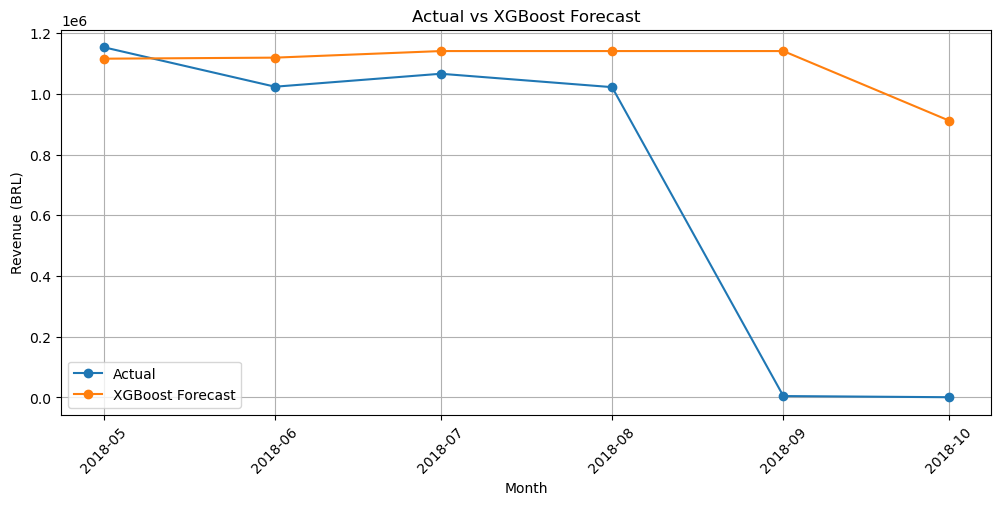

In [398]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    forecast_results["month"],
    forecast_results["revenue"],
    marker="o",
    label="Actual"
)

plt.plot(
    forecast_results["month"],
    forecast_results["predicted"],
    marker="o",
    label="XGBoost Forecast"
)

plt.title("Actual vs XGBoost Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

## 12. Model Comparison

The forecasting models were evaluated using a six-month holdout test set.

| Model | Approach | Features Used | MAE (BRL) | RMSE (BRL) |
|-------|----------|---------------|-----------|------------|
| ARIMA | Statistical Time-Series Model | Historical revenue values | 502,347.62 | 710,644.07 |
| XGBoost | Machine Learning Model | Time features, lag variables, rolling statistics | 395,933.95 | 599,111.31 |

### Result

XGBoost achieved better forecasting performance compared with ARIMA, reducing:

- MAE by approximately **21%**
- RMSE by approximately **16%**

The improvement was driven by additional feature engineering, including lag variables and rolling revenue trends, which allowed the model to capture recent sales patterns more effectively.

## 13. Feature Importance

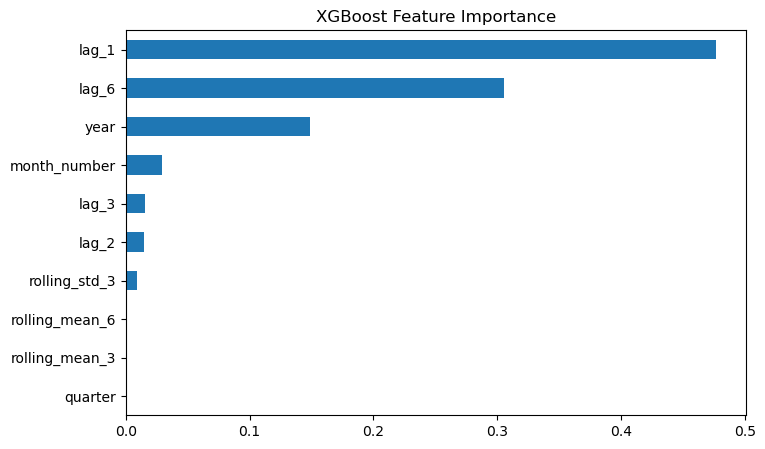

In [399]:
importance = (
    pd.Series(
        model.feature_importances_,
        index=features
    )
    .sort_values()
)

importance.plot(kind="barh", figsize=(8,5))

plt.title("XGBoost Feature Importance")
plt.show()

## 14. Conclusion

**Final Project Summary**

**E-Commerce Revenue Forecasting | Python, Pandas, ARIMA, XGBoost**

Developed a revenue forecasting pipeline using the Olist Brazilian e-commerce dataset. Integrated order and payment data, transformed transaction-level records into monthly revenue trends, and performed exploratory time-series analysis. Built and compared ARIMA and XGBoost forecasting models, engineering time-based features including lag variables and rolling statistics. Evaluated models using a six-month holdout test set, with XGBoost achieving the strongest performance (MAE: 395.9K BRL, RMSE: 599.1K BRL). Generated revenue forecasts to support sales planning and data-driven decision-making.
